# Stroke Risk Prediction System

### Problem Statement
Stroke is one of the leading causes of death and disability worldwide...

### Goal
The goal is to build a machine learning system capable of predicting stroke risk based on patient health information.

### 1. Importing libraries

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

### 2. Load Dataset

In [52]:
df = pd.read_csv("./StrockDataset.csv")

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### 3. Initial Data Exploration

In [53]:
df.shape

(5110, 12)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [55]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [56]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### 4. Exploratory Data Analysis

#### Stroke Distribution

<Axes: xlabel='stroke', ylabel='count'>

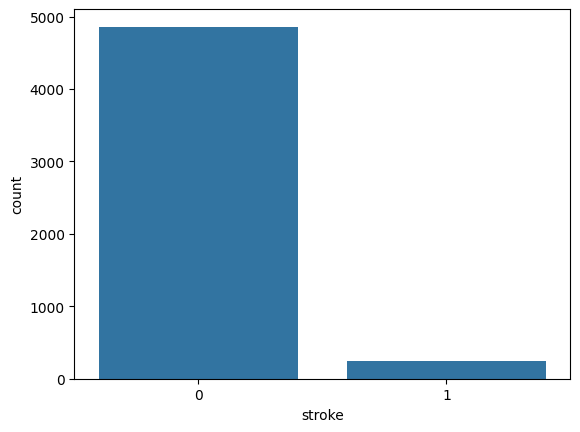

In [57]:
sns.countplot(x='stroke', data=df)

#### Age Distribution

<Axes: xlabel='age', ylabel='Count'>

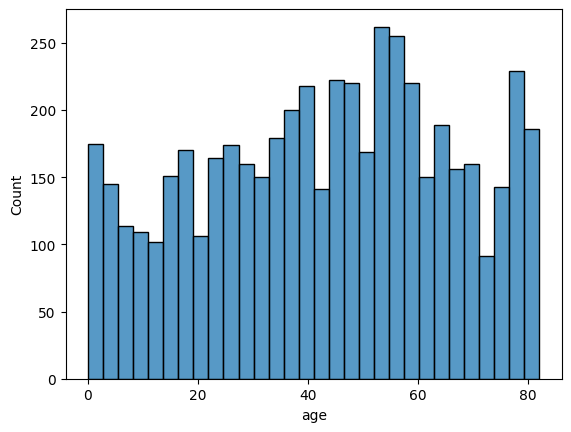

In [58]:
sns.histplot(df['age'], bins=30)

#### Avarage Glucose level vs Stroke

<Axes: xlabel='stroke', ylabel='avg_glucose_level'>

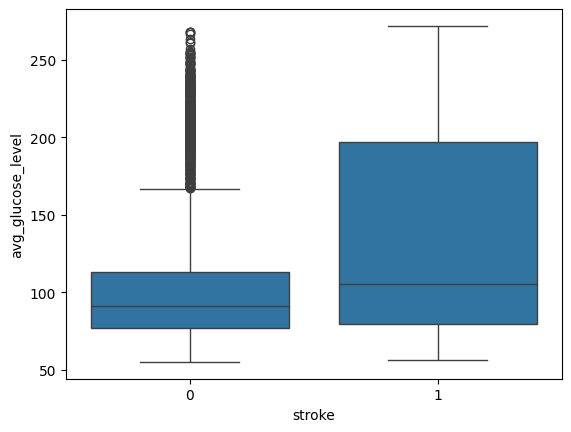

In [59]:
sns.boxplot(x='stroke', y='avg_glucose_level', data=df)

#### BMI vs Stroke

<Axes: xlabel='stroke', ylabel='bmi'>

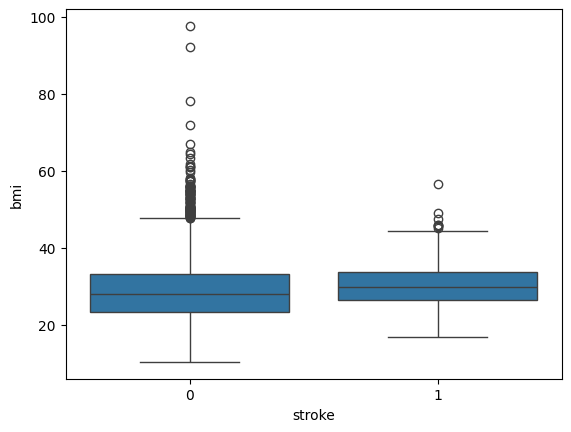

In [60]:
sns.boxplot(x='stroke', y='bmi', data=df)

#### Smoking status analysis

<Axes: xlabel='smoking_status', ylabel='count'>

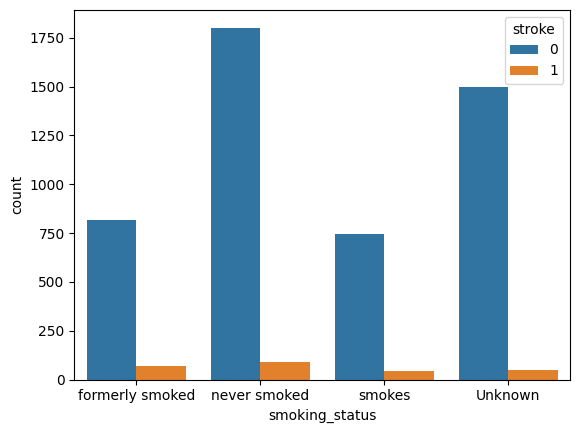

In [61]:
sns.countplot(x='smoking_status', hue='stroke', data=df)

#### Correlation Heatmap

In [62]:
# You’ll need encoded numeric columns first.

### 5. Data Preprocessing

#### Remove Unnecessary Columns

In [63]:
# id should be removed.
df = df.drop('id', axis=1)

#### Handle Missing Valuesm

In [64]:
# BMI has missing values.
df['bmi'].fillna(df['bmi'].median(), inplace=True)

/tmp/ipykernel_13015/206245230.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)


#### Encode Categorical Features

Columns like:

- gender  
- work_type  
- Residence_type  
- smoking_status  

Use OneHotEncoding.

#### Feature Scaling

StandardScaler.  
Especially useful for:  

- Logistic Regression
- SVM

### 6. Feature Engineering

#### Age Groups

In [65]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 40, 60, 100],
    labels=['Child', 'Young Adult', 'Adult', 'Senior']
)

#### BMI Categories

In [66]:
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

#### Hypertension + Heart Disease Combined Risk

In [67]:
df['cardio_risk'] = (
    df['hypertension'] + df['heart_disease']
)

#### 7. Train/Test Split

In [68]:
X = df.drop('stroke', axis=1)
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### 8. Model Selection

| Model               | Why                             |
| ------------------- | ------------------------------- |
| Logistic Regression | interpretable baseline          |
| Random Forest       | handles nonlinear relationships |

Optional:
- XGBoost
- LightGBM

### 9. Training Pipeline

In [69]:
numeric_features = ['age', 'avg_glucose_level', 'bmi']
categorical_features = [...]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [70]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

### 10. Evaluation Metrics

| Metric    | Why                          |
| --------- | ---------------------------- |
| Accuracy  | overall correctness          |
| Precision | false positive control       |
| Recall    | VERY important in healthcare |
| F1-score  | balance                      |
| ROC-AUC   | classification quality       |


### 11. Confusion Matrix

In [71]:
sns.heatmap(cm, annot=True, fmt='d')

NameError: name 'cm' is not defined

- False negatives are dangerous in stroke prediction.

### 12. Feature Importance

In [73]:
# if using rondom forest
feature_importances_
#Then plot top features.

NameError: name 'feature_importances_' is not defined

### 13. Risk Translation Layer

This directly satisfies:

“translation of model predictions”

Do NOT return only 0 or 1.

Use probabilities.

Example:


In [74]:
prob = model.predict_proba(sample)[0][1]

NameError: name 'model' is not defined

In [75]:
if prob < 0.3:
    risk = "Low Risk"
elif prob < 0.7:
    risk = "Medium Risk"
else:
    risk = "High Risk"

NameError: name 'prob' is not defined

### 15. Conclusions

Include:

- best model
- important features
- limitations
- future improvements

Example:

- more data needed
- clinical validation needed
- dataset imbalance issue
- deep learning possibilities